In [2]:
import os
import pandas as pd
from pathlib import Path
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Set the path to the datasets folder
# Try both png_265 and png_256 in case of typo
possible_paths = [
    "../../datasets/ADDA/png_265",
    "../../datasets/ADDA/png_256"
]

target_path = None
for path in possible_paths:
    if os.path.exists(path):
        target_path = path
        print(f"Found directory: {path}")
        break

if target_path is None:
    print("Neither png_265 nor png_256 directories found.")
    print("Available directories in ../../datasets/ADDA/:")
    adda_path = "../../datasets/ADDA"
    if os.path.exists(adda_path):
        for item in os.listdir(adda_path):
            print(f"  - {item}")
else:
    print(f"Analyzing directory: {target_path}")
    
    # Get all files recursively
    all_files = []
    for root, dirs, files in os.walk(target_path):
        for file in files:
            file_path = os.path.join(root, file)
            rel_path = os.path.relpath(file_path, target_path)
            file_size = os.path.getsize(file_path)
            file_ext = os.path.splitext(file)[1].lower()
            
            all_files.append({
                'file_path': rel_path,
                'full_path': file_path,
                'file_name': file,
                'file_size': file_size,
                'file_extension': file_ext,
                'directory': os.path.dirname(rel_path) if os.path.dirname(rel_path) else '.'
            })
    
    print(f"\nTotal files found: {len(all_files)}")
    
    # Create DataFrame for analysis
    df = pd.DataFrame(all_files)
    
    # Basic statistics
    print(f"\n=== DIRECTORY SUMMARY ===")
    print(f"Total files: {len(df)}")
    print(f"Total size: {df['file_size'].sum() / (1024**3):.2f} GB")
    print(f"Average file size: {df['file_size'].mean() / (1024**2):.2f} MB")
    print(f"Largest file: {df.loc[df['file_size'].idxmax(), 'file_name']} ({df['file_size'].max() / (1024**2):.2f} MB)")
    print(f"Smallest file: {df.loc[df['file_size'].idxmin(), 'file_name']} ({df['file_size'].min() / 1024:.2f} KB)")
    
    # File extensions
    print(f"\n=== FILE EXTENSIONS ===")
    ext_counts = df['file_extension'].value_counts()
    for ext, count in ext_counts.items():
        print(f"{ext or 'no extension'}: {count} files")
    
    # Directory structure
    print(f"\n=== DIRECTORY STRUCTURE ===")
    dir_counts = df['directory'].value_counts()
    print(f"Number of subdirectories: {len(dir_counts)}")
    print("\nTop 10 directories by file count:")
    for dir_name, count in dir_counts.head(10).items():
        print(f"  {dir_name}: {count} files")
    
    # File size distribution
    print(f"\n=== FILE SIZE DISTRIBUTION ===")
    size_ranges = [
        (0, 1024, "0-1 KB"),
        (1024, 1024*1024, "1 KB-1 MB"),
        (1024*1024, 10*1024*1024, "1-10 MB"),
        (10*1024*1024, 100*1024*1024, "10-100 MB"),
        (100*1024*1024, float('inf'), ">100 MB")
    ]
    
    for min_size, max_size, label in size_ranges:
        count = len(df[(df['file_size'] >= min_size) & (df['file_size'] < max_size)])
        if count > 0:
            print(f"  {label}: {count} files")
    
    # Sample files
    print(f"\n=== SAMPLE FILES ===")
    print("First 10 files:")
    for i, row in df.head(10).iterrows():
        print(f"  {row['file_path']} ({row['file_size'] / 1024:.1f} KB)")
    
    if len(df) > 10:
        print(f"\nLast 10 files:")
        for i, row in df.tail(10).iterrows():
            print(f"  {row['file_path']} ({row['file_size'] / 1024:.1f} KB)")
    
    # Save detailed summary to CSV
    summary_file = "file_summary.csv"
    df.to_csv(summary_file, index=False)
    print(f"\nDetailed file list saved to: {summary_file}")
    
    # Display the DataFrame
    print(f"\n=== FULL FILE LIST ===")
    display(df)


Found directory: ../../datasets/ADDA/png_256
Analyzing directory: ../../datasets/ADDA/png_256

Total files found: 13412

=== DIRECTORY SUMMARY ===
Total files: 13412
Total size: 0.12 GB
Average file size: 0.01 MB
Largest file: dataset.csv (0.46 MB)
Smallest file: MDA-084__CT_62.txt (0.04 KB)

=== FILE EXTENSIONS ===
.png: 8046 files
.txt: 5364 files
no extension: 1 files
.csv: 1 files

=== DIRECTORY STRUCTURE ===
Number of subdirectories: 4

Top 10 directories by file count:
  images: 5364 files
  yolo_labels: 5364 files
  labels: 2682 files
  .: 2 files

=== FILE SIZE DISTRIBUTION ===
  0-1 KB: 6155 files
  1 KB-1 MB: 7257 files

=== SAMPLE FILES ===
First 10 files:
  .DS_Store (10.0 KB)
  dataset.csv (473.0 KB)
  images/MDA-039__PT_58.png (16.8 KB)
  images/MDA-160__CT_61.png (26.7 KB)
  images/CHUP-018__CT_230.png (37.0 KB)
  images/CHUP-018__CT_224.png (37.5 KB)
  images/MDA-156__PT_74.png (17.3 KB)
  images/MDA-038__CT_65.png (34.3 KB)
  images/MDA-039__PT_64.png (19.7 KB)
  image

,file_path,full_path,file_name,file_size,file_extension,directory
0,.DS_Store,../../datasets/ADDA/png_256/.DS_Store,.DS_Store,10244,,.
1,dataset.csv,../../datasets/ADDA/png_256/dataset.csv,dataset.csv,484325,.csv,.
2,images/MDA-039__PT_58.png,../../datasets/ADDA/png_256/images/MDA-039__PT...,MDA-039__PT_58.png,17233,.png,images
3,images/MDA-160__CT_61.png,../../datasets/ADDA/png_256/images/MDA-160__CT...,MDA-160__CT_61.png,27321,.png,images
4,images/CHUP-018__CT_230.png,../../datasets/ADDA/png_256/images/CHUP-018__C...,CHUP-018__CT_230.png,37928,.png,images
...,...,...,...,...,...,...
13407,yolo_labels/MDA-154__PT_79.txt,../../datasets/ADDA/png_256/yolo_labels/MDA-15...,MDA-154__PT_79.txt,37,.txt,yolo_labels
13408,yolo_labels/CHUP-057__CT_236.txt,../../datasets/ADDA/png_256/yolo_labels/CHUP-0...,CHUP-057__CT_236.txt,75,.txt,yolo_labels
13409,yolo_labels/MDA-021__PT_63.txt,../../datasets/ADDA/png_256/yolo_labels/MDA-02...,MDA-021__PT_63.txt,37,.txt,yolo_labels
13410,yolo_labels/CHUP-042__PT_242.txt,../../datasets/ADDA/png_256/yolo_labels/CHUP-0...,CHUP-042__PT_242.txt,37,.txt,yolo_labels


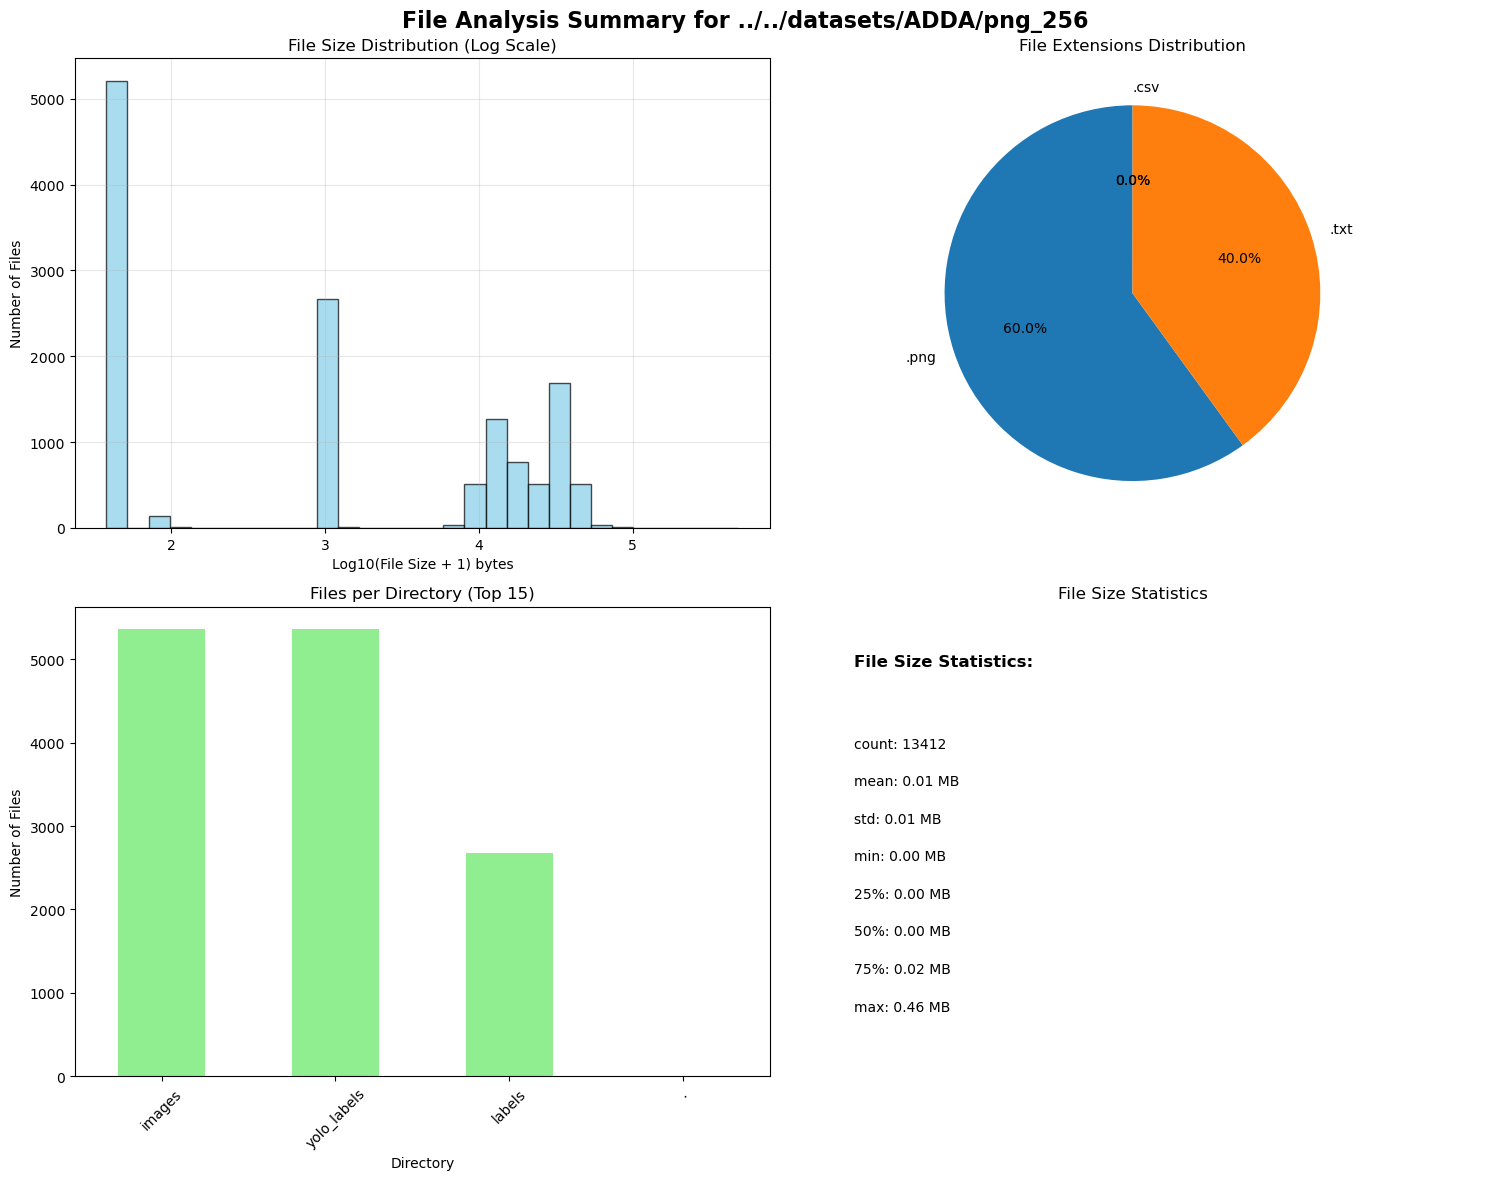


=== DETAILED STATISTICS ===
File size statistics (in MB):
count    0.012791
mean     0.009509
std      0.013798
min      0.000035
25%      0.000035
50%      0.000995
75%      0.015180
max      0.461888
Name: file_size, dtype: float64

Directory depth analysis:
  Depth 0: 2 files
  Depth 1: 13410 files


In [3]:
# Create visualizations if we have data
if 'df' in locals() and len(df) > 0:
    # Set up the plotting style
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'File Analysis Summary for {target_path}', fontsize=16, fontweight='bold')
    
    # 1. File size distribution (log scale)
    axes[0, 0].hist(np.log10(df['file_size'] + 1), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].set_xlabel('Log10(File Size + 1) bytes')
    axes[0, 0].set_ylabel('Number of Files')
    axes[0, 0].set_title('File Size Distribution (Log Scale)')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. File extensions pie chart
    ext_counts = df['file_extension'].value_counts()
    if len(ext_counts) <= 10:  # Only show pie chart if not too many extensions
        axes[0, 1].pie(ext_counts.values, labels=ext_counts.index, autopct='%1.1f%%', startangle=90)
        axes[0, 1].set_title('File Extensions Distribution')
    else:
        # Bar chart for many extensions
        ext_counts.head(10).plot(kind='bar', ax=axes[0, 1], color='lightcoral')
        axes[0, 1].set_title('Top 10 File Extensions')
        axes[0, 1].set_xlabel('File Extension')
        axes[0, 1].set_ylabel('Count')
        axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. Directory file count (top 15)
    dir_counts = df['directory'].value_counts()
    dir_counts.head(15).plot(kind='bar', ax=axes[1, 0], color='lightgreen')
    axes[1, 0].set_title('Files per Directory (Top 15)')
    axes[1, 0].set_xlabel('Directory')
    axes[1, 0].set_ylabel('Number of Files')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # 4. File size vs count scatter (if not too many files)
    if len(df) <= 1000:  # Only for smaller datasets
        axes[1, 1].scatter(range(len(df)), df['file_size'] / (1024*1024), alpha=0.6, color='purple')
        axes[1, 1].set_xlabel('File Index')
        axes[1, 1].set_ylabel('File Size (MB)')
        axes[1, 1].set_title('File Size Distribution')
        axes[1, 1].grid(True, alpha=0.3)
    else:
        # Show file size statistics instead
        size_stats = df['file_size'].describe()
        axes[1, 1].text(0.1, 0.8, f"File Size Statistics:\n\n", fontsize=12, fontweight='bold', 
                        transform=axes[1, 1].transAxes)
        y_pos = 0.7
        for stat, value in size_stats.items():
            if stat == 'count':
                axes[1, 1].text(0.1, y_pos, f"{stat}: {int(value)}", fontsize=10, 
                               transform=axes[1, 1].transAxes)
            else:
                axes[1, 1].text(0.1, y_pos, f"{stat}: {value/1024/1024:.2f} MB", fontsize=10, 
                               transform=axes[1, 1].transAxes)
            y_pos -= 0.08
        axes[1, 1].set_title('File Size Statistics')
        axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Additional summary statistics
    print(f"\n=== DETAILED STATISTICS ===")
    print(f"File size statistics (in MB):")
    print(df['file_size'].describe() / (1024*1024))
    
    print(f"\nDirectory depth analysis:")
    df['depth'] = df['file_path'].str.count('/')
    depth_counts = df['depth'].value_counts().sort_index()
    for depth, count in depth_counts.items():
        print(f"  Depth {depth}: {count} files")
        
else:
    print("No data available for visualization.")


In [ ]:
# Analyze images and labels in the ADDA png_256 dataset
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import re

In [11]:


# Set paths
images_path = "../../datasets/ADDA/png_256/images"
labels_path = "../../datasets/ADDA/png_256/labels"

print("=== ADDA PNG_256 DATASET ANALYSIS ===")
print(f"Images path: {images_path}")
print(f"Labels path: {labels_path}")

# Check if paths exist
if not os.path.exists(images_path):
    print(f"❌ Images path does not exist: {images_path}")
    exit()
if not os.path.exists(labels_path):
    print(f"❌ Labels path does not exist: {labels_path}")
    exit()

print("✅ Both paths exist")

# Get all files from both directories
image_files = []
label_files = []

# Get image files
for file in os.listdir(images_path):
    if file.lower().endswith(('.png', '.jpg', '.jpeg')):
        image_files.append(file)

# Get label files  
for file in os.listdir(labels_path):
    if file.lower().endswith(('.png', '.jpg', '.jpeg')):
        label_files.append(file)

print(f"\n📊 FILE COUNTS:")
print(f"Total image files: {len(image_files)}")
print(f"Total label files: {len(label_files)}")

# Parse image files to identify CT and PT
ct_files = []
pt_files = []

for file in image_files:
    if '_CT_' in file:
        ct_files.append(file)
    elif '_PT_' in file:
        pt_files.append(file)

print(f"CT files: {len(ct_files)}")
print(f"PT files: {len(pt_files)}")

# Debug: Show sample filenames
if len(image_files) > 0:
    print(f"\n🔍 SAMPLE IMAGE FILES:")
    for i, file in enumerate(image_files[:5]):
        print(f"  {i+1}. {file}")
    if len(image_files) > 5:
        print(f"  ... and {len(image_files) - 5} more")

if len(label_files) > 0:
    print(f"\n🔍 SAMPLE LABEL FILES:")
    for i, file in enumerate(label_files[:5]):
        print(f"  {i+1}. {file}")
    if len(label_files) > 5:
        print(f"  ... and {len(label_files) - 5} more")

# Extract patient IDs and slice numbers from files
def extract_patient_slice(filename):
    """Extract patient ID and slice number from filename"""
    # Pattern: PATIENT_ID_CT/PT_SLICE.png
    match = re.match(r'([^_]+)_(CT|PT)_(\d+)\.png', filename)
    if match:
        return match.group(1), match.group(2), int(match.group(3))
    return None, None, None

def extract_label_patient_slice(filename):
    """Extract patient ID and slice number from label filename"""
    # Pattern: PATIENT_ID_SLICE.png
    match = re.match(r'([^_]+)_(\d+)\.png', filename)
    if match:
        return match.group(1), int(match.group(2))
    return None, None

# Parse CT files
ct_data = []
for file in ct_files:
    patient, modality, slice_num = extract_patient_slice(file)
    if patient:
        ct_data.append({
            'filename': file,
            'patient_id': patient,
            'modality': modality,
            'slice_number': slice_num,
            'file_type': 'CT'
        })

# Parse PT files
pt_data = []
for file in pt_files:
    patient, modality, slice_num = extract_patient_slice(file)
    if patient:
        pt_data.append({
            'filename': file,
            'patient_id': patient,
            'modality': modality,
            'slice_number': slice_num,
            'file_type': 'PT'
        })

# Parse label files
label_data = []
for file in label_files:
    patient, slice_num = extract_label_patient_slice(file)
    if patient:
        label_data.append({
            'filename': file,
            'patient_id': patient,
            'slice_number': slice_num,
            'file_type': 'LABEL'
        })

# Create DataFrames
ct_df = pd.DataFrame(ct_data)
pt_df = pd.DataFrame(pt_data)
label_df = pd.DataFrame(label_data)

print(f"\n📋 PARSED DATA:")
print(f"CT files parsed: {len(ct_df)}")
print(f"PT files parsed: {len(pt_df)}")
print(f"Label files parsed: {len(label_df)}")

# Debug: Show parsing results
if len(ct_df) > 0:
    print(f"\n🔍 SAMPLE CT PARSED FILES:")
    for i, row in ct_df.head(3).iterrows():
        print(f"  {row['filename']} -> Patient: {row['patient_id']}, Slice: {row['slice_number']}")

if len(pt_df) > 0:
    print(f"\n🔍 SAMPLE PT PARSED FILES:")
    for i, row in pt_df.head(3).iterrows():
        print(f"  {row['filename']} -> Patient: {row['patient_id']}, Slice: {row['slice_number']}")

if len(label_df) > 0:
    print(f"\n🔍 SAMPLE LABEL PARSED FILES:")
    for i, row in label_df.head(3).iterrows():
        print(f"  {row['filename']} -> Patient: {row['patient_id']}, Slice: {row['slice_number']}")

# Check for parsing issues
if len(ct_files) > 0 and len(ct_df) == 0:
    print(f"\n⚠️  WARNING: {len(ct_files)} CT files found but none parsed successfully!")
    print("Check the filename pattern - expected: PATIENT_ID_CT_SLICE.png")

if len(pt_files) > 0 and len(pt_df) == 0:
    print(f"\n⚠️  WARNING: {len(pt_files)} PT files found but none parsed successfully!")
    print("Check the filename pattern - expected: PATIENT_ID_PT_SLICE.png")

if len(label_files) > 0 and len(label_df) == 0:
    print(f"\n⚠️  WARNING: {len(label_files)} label files found but none parsed successfully!")
    print("Check the filename pattern - expected: PATIENT_ID_SLICE.png")

# Find unique patient IDs
all_patients = set()
if len(ct_df) > 0:
    all_patients.update(ct_df['patient_id'].unique())
if len(pt_df) > 0:
    all_patients.update(pt_df['patient_id'].unique())
if len(label_df) > 0:
    all_patients.update(label_df['patient_id'].unique())

print(f"\n👥 PATIENT ANALYSIS:")
print(f"Unique patients: {len(all_patients)}")
print(f"Patients with CT: {len(ct_df['patient_id'].unique()) if len(ct_df) > 0 else 0}")
print(f"Patients with PT: {len(pt_df['patient_id'].unique()) if len(pt_df) > 0 else 0}")
print(f"Patients with labels: {len(label_df['patient_id'].unique()) if len(label_df) > 0 else 0}")

# Check for complete triplets (CT + PT + Label)
print(f"\n🔍 TRIPLET ANALYSIS:")
complete_triplets = 0
missing_ct = 0
missing_pt = 0
missing_label = 0

triplet_analysis = []

if len(all_patients) == 0:
    print("No patients found to analyze!")
else:
    for patient in all_patients:
        patient_ct = ct_df[ct_df['patient_id'] == patient] if len(ct_df) > 0 else pd.DataFrame(columns=['filename', 'patient_id', 'modality', 'slice_number', 'file_type'])
        patient_pt = pt_df[pt_df['patient_id'] == patient] if len(pt_df) > 0 else pd.DataFrame(columns=['filename', 'patient_id', 'modality', 'slice_number', 'file_type'])
        patient_labels = label_df[label_df['patient_id'] == patient] if len(label_df) > 0 else pd.DataFrame(columns=['filename', 'patient_id', 'slice_number', 'file_type'])
        
        # Get all slice numbers for this patient
        ct_slices = set(patient_ct['slice_number'].unique()) if len(patient_ct) > 0 else set()
        pt_slices = set(patient_pt['slice_number'].unique()) if len(patient_pt) > 0 else set()
        label_slices = set(patient_labels['slice_number'].unique()) if len(patient_labels) > 0 else set()
        
        # Find common slices
        common_slices = ct_slices & pt_slices & label_slices
        
        for slice_num in common_slices:
            complete_triplets += 1
            triplet_analysis.append({
                'patient_id': patient,
                'slice_number': slice_num,
                'has_ct': True,
                'has_pt': True,
                'has_label': True,
                'status': 'COMPLETE'
            })
        
        # Check for missing components
        for slice_num in ct_slices:
            if slice_num not in pt_slices:
                missing_pt += 1
                triplet_analysis.append({
                    'patient_id': patient,
                    'slice_number': slice_num,
                    'has_ct': True,
                    'has_pt': False,
                    'has_label': slice_num in label_slices,
                    'status': 'MISSING_PT'
                })
            if slice_num not in label_slices:
                missing_label += 1
        
        for slice_num in pt_slices:
            if slice_num not in ct_slices:
                missing_ct += 1
                triplet_analysis.append({
                    'patient_id': patient,
                    'slice_number': slice_num,
                    'has_ct': False,
                    'has_pt': True,
                    'has_label': slice_num in label_slices,
                    'status': 'MISSING_CT'
                })

print(f"Complete triplets (CT+PT+Label): {complete_triplets}")
print(f"Missing CT files: {missing_ct}")
print(f"Missing PT files: {missing_pt}")
print(f"Missing Label files: {missing_label}")

# Create triplet analysis DataFrame
if len(triplet_analysis) > 0:
    triplet_df = pd.DataFrame(triplet_analysis)
else:
    # Create empty DataFrame with expected columns
    triplet_df = pd.DataFrame(columns=['patient_id', 'slice_number', 'has_ct', 'has_pt', 'has_label', 'status'])

# Slice number distribution
print(f"\n📈 SLICE DISTRIBUTION:")
if len(ct_df) > 0 and 'slice_number' in ct_df.columns:
    print(f"CT slices per patient:")
    ct_slices_per_patient = ct_df.groupby('patient_id')['slice_number'].count()
    print(f"  Mean: {ct_slices_per_patient.mean():.1f}")
    print(f"  Min: {ct_slices_per_patient.min()}")
    print(f"  Max: {ct_slices_per_patient.max()}")
else:
    print("CT slices per patient: No data available")

if len(pt_df) > 0 and 'slice_number' in pt_df.columns:
    print(f"PT slices per patient:")
    pt_slices_per_patient = pt_df.groupby('patient_id')['slice_number'].count()
    print(f"  Mean: {pt_slices_per_patient.mean():.1f}")
    print(f"  Min: {pt_slices_per_patient.min()}")
    print(f"  Max: {pt_slices_per_patient.max()}")
else:
    print("PT slices per patient: No data available")

if len(label_df) > 0 and 'slice_number' in label_df.columns:
    print(f"Label slices per patient:")
    label_slices_per_patient = label_df.groupby('patient_id')['slice_number'].count()
    print(f"  Mean: {label_slices_per_patient.mean():.1f}")
    print(f"  Min: {label_slices_per_patient.min()}")
    print(f"  Max: {label_slices_per_patient.max()}")
else:
    print("Label slices per patient: No data available")

# Show sample of complete triplets
print(f"\n✅ SAMPLE COMPLETE TRIPLETS:")
if len(triplet_df) > 0 and 'status' in triplet_df.columns:
    complete_triplets_df = triplet_df[triplet_df['status'] == 'COMPLETE']
    if len(complete_triplets_df) > 0:
        sample_triplets = complete_triplets_df.head(10)
        for _, row in sample_triplets.iterrows():
            print(f"  {row['patient_id']}_slice_{row['slice_number']}: CT ✓ PT ✓ Label ✓")
    else:
        print("  No complete triplets found!")
else:
    print("  No triplet analysis data available!")

# Show sample missing files
print(f"\n❌ SAMPLE MISSING FILES:")
if len(triplet_df) > 0 and 'status' in triplet_df.columns:
    missing_files = triplet_df[triplet_df['status'] != 'COMPLETE']
    if len(missing_files) > 0:
        sample_missing = missing_files.head(10)
        for _, row in sample_missing.iterrows():
            status = row['status']
            ct_status = "✓" if row['has_ct'] else "✗"
            pt_status = "✓" if row['has_pt'] else "✗"
            label_status = "✓" if row['has_label'] else "✗"
            print(f"  {row['patient_id']}_slice_{row['slice_number']}: CT {ct_status} PT {pt_status} Label {label_status} ({status})")
    else:
        print("  No missing files found!")
else:
    print("  No triplet analysis data available!")

print(f"\n📊 SUMMARY:")
print(f"Total files: {len(image_files) + len(label_files)}")
print(f"Complete triplets: {complete_triplets}")

# Calculate completion rate safely
max_files = max(len(ct_df), len(pt_df), len(label_df))
if max_files > 0:
    completion_rate = (complete_triplets / max_files) * 100
    print(f"Completion rate: {completion_rate:.1f}%")
else:
    print("Completion rate: Cannot calculate (no files found)")

# Additional summary information
print(f"\n📋 DATASET STATUS:")
if len(all_patients) == 0:
    print("❌ No patients found in the dataset")
    print("This could mean:")
    print("  - The directories are empty")
    print("  - The filename patterns don't match expected format")
    print("  - Files are in a different location")
elif len(ct_df) == 0 and len(pt_df) == 0 and len(label_df) == 0:
    print("❌ No files were successfully parsed")
    print("This could mean:")
    print("  - Filename patterns don't match expected format")
    print("  - Files have different extensions")
    print("  - Directory structure is different than expected")
else:
    print("✅ Dataset analysis completed successfully")
    print(f"  - Found {len(all_patients)} unique patients")
    print(f"  - Parsed {len(ct_df)} CT files")
    print(f"  - Parsed {len(pt_df)} PT files") 
    print(f"  - Parsed {len(label_df)} label files")


=== ADDA PNG_256 DATASET ANALYSIS ===
Images path: ../../datasets/ADDA/png_256/images
Labels path: ../../datasets/ADDA/png_256/labels
✅ Both paths exist

📊 FILE COUNTS:
Total image files: 5364
Total label files: 2682
CT files: 2682
PT files: 2682

🔍 SAMPLE IMAGE FILES:
  1. MDA-039__PT_58.png
  2. MDA-160__CT_61.png
  3. CHUP-018__CT_230.png
  4. CHUP-018__CT_224.png
  5. MDA-156__PT_74.png
  ... and 5359 more

🔍 SAMPLE LABEL FILES:
  1. MDA-096_68.png
  2. MDA-141_56.png
  3. MDA-196_68.png
  4. MDA-111_252.png
  5. MDA-101_246.png
  ... and 2677 more

📋 PARSED DATA:
CT files parsed: 0
PT files parsed: 0
Label files parsed: 2682

🔍 SAMPLE LABEL PARSED FILES:
  MDA-096_68.png -> Patient: MDA-096, Slice: 68
  MDA-141_56.png -> Patient: MDA-141, Slice: 56
  MDA-196_68.png -> Patient: MDA-196, Slice: 68

⚠️  WARNING: 2682 CT files found but none parsed successfully!
Check the filename pattern - expected: PATIENT_ID_CT_SLICE.png

⚠️  WARNING: 2682 PT files found but none parsed successfull

In [12]:
# CORRECTED VERSION - Fix the filename patterns
# The actual patterns are:
# CT files: XXX-123__CT_123.png (double underscore before CT)
# PT files: XXX-123__PT_123.png (double underscore before PT)  
# Labels: XXX-123_123.png (single underscore between patient ID and slice)

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import re

# Set paths
images_path = "../../datasets/ADDA/png_256/images"
labels_path = "../../datasets/ADDA/png_256/labels"

print("=== ADDA PNG_256 DATASET ANALYSIS (CORRECTED) ===")
print(f"Images path: {images_path}")
print(f"Labels path: {labels_path}")

# Check if paths exist
if not os.path.exists(images_path):
    print(f"❌ Images path does not exist: {images_path}")
    exit()
if not os.path.exists(labels_path):
    print(f"❌ Labels path does not exist: {labels_path}")
    exit()

print("✅ Both paths exist")

# Get all files from both directories
image_files = []
label_files = []

# Get image files
for file in os.listdir(images_path):
    if file.lower().endswith(('.png', '.jpg', '.jpeg')):
        image_files.append(file)

# Get label files  
for file in os.listdir(labels_path):
    if file.lower().endswith(('.png', '.jpg', '.jpeg')):
        label_files.append(file)

print(f"\n📊 FILE COUNTS:")
print(f"Total image files: {len(image_files)}")
print(f"Total label files: {len(label_files)}")

# Parse image files to identify CT and PT with CORRECTED patterns
ct_files = []
pt_files = []

for file in image_files:
    if '__CT_' in file:  # Double underscore before CT
        ct_files.append(file)
    elif '__PT_' in file:  # Double underscore before PT
        pt_files.append(file)

print(f"CT files: {len(ct_files)}")
print(f"PT files: {len(pt_files)}")

# Debug: Show sample filenames
if len(image_files) > 0:
    print(f"\n🔍 SAMPLE IMAGE FILES:")
    for i, file in enumerate(image_files[:5]):
        print(f"  {i+1}. {file}")
    if len(image_files) > 5:
        print(f"  ... and {len(image_files) - 5} more")

if len(label_files) > 0:
    print(f"\n🔍 SAMPLE LABEL FILES:")
    for i, file in enumerate(label_files[:5]):
        print(f"  {i+1}. {file}")
    if len(label_files) > 5:
        print(f"  ... and {len(label_files) - 5} more")

# CORRECTED regex patterns
def extract_patient_slice(filename):
    """Extract patient ID and slice number from filename"""
    # Pattern: PATIENT_ID__CT/PT_SLICE.png (double underscore)
    match = re.match(r'([^_]+)__(CT|PT)_(\d+)\.png', filename)
    if match:
        return match.group(1), match.group(2), int(match.group(3))
    return None, None, None

def extract_label_patient_slice(filename):
    """Extract patient ID and slice number from label filename"""
    # Pattern: PATIENT_ID_SLICE.png (single underscore)
    match = re.match(r'([^_]+)_(\d+)\.png', filename)
    if match:
        return match.group(1), int(match.group(2))
    return None, None

# Parse CT files
ct_data = []
for file in ct_files:
    patient, modality, slice_num = extract_patient_slice(file)
    if patient:
        ct_data.append({
            'filename': file,
            'patient_id': patient,
            'modality': modality,
            'slice_number': slice_num,
            'file_type': 'CT'
        })

# Parse PT files
pt_data = []
for file in pt_files:
    patient, modality, slice_num = extract_patient_slice(file)
    if patient:
        pt_data.append({
            'filename': file,
            'patient_id': patient,
            'modality': modality,
            'slice_number': slice_num,
            'file_type': 'PT'
        })

# Parse label files
label_data = []
for file in label_files:
    patient, slice_num = extract_label_patient_slice(file)
    if patient:
        label_data.append({
            'filename': file,
            'patient_id': patient,
            'slice_number': slice_num,
            'file_type': 'LABEL'
        })

# Create DataFrames
ct_df = pd.DataFrame(ct_data)
pt_df = pd.DataFrame(pt_data)
label_df = pd.DataFrame(label_data)

print(f"\n📋 PARSED DATA:")
print(f"CT files parsed: {len(ct_df)}")
print(f"PT files parsed: {len(pt_df)}")
print(f"Label files parsed: {len(label_df)}")

# Debug: Show parsing results
if len(ct_df) > 0:
    print(f"\n🔍 SAMPLE CT PARSED FILES:")
    for i, row in ct_df.head(3).iterrows():
        print(f"  {row['filename']} -> Patient: {row['patient_id']}, Slice: {row['slice_number']}")

if len(pt_df) > 0:
    print(f"\n🔍 SAMPLE PT PARSED FILES:")
    for i, row in pt_df.head(3).iterrows():
        print(f"  {row['filename']} -> Patient: {row['patient_id']}, Slice: {row['slice_number']}")

if len(label_df) > 0:
    print(f"\n🔍 SAMPLE LABEL PARSED FILES:")
    for i, row in label_df.head(3).iterrows():
        print(f"  {row['filename']} -> Patient: {row['patient_id']}, Slice: {row['slice_number']}")

# Check for parsing issues
if len(ct_files) > 0 and len(ct_df) == 0:
    print(f"\n⚠️  WARNING: {len(ct_files)} CT files found but none parsed successfully!")
    print("Check the filename pattern - expected: PATIENT_ID__CT_SLICE.png")

if len(pt_files) > 0 and len(pt_df) == 0:
    print(f"\n⚠️  WARNING: {len(pt_files)} PT files found but none parsed successfully!")
    print("Check the filename pattern - expected: PATIENT_ID__PT_SLICE.png")

if len(label_files) > 0 and len(label_df) == 0:
    print(f"\n⚠️  WARNING: {len(label_files)} label files found but none parsed successfully!")
    print("Check the filename pattern - expected: PATIENT_ID_SLICE.png")

# Find unique patient IDs
all_patients = set()
if len(ct_df) > 0:
    all_patients.update(ct_df['patient_id'].unique())
if len(pt_df) > 0:
    all_patients.update(pt_df['patient_id'].unique())
if len(label_df) > 0:
    all_patients.update(label_df['patient_id'].unique())

print(f"\n👥 PATIENT ANALYSIS:")
print(f"Unique patients: {len(all_patients)}")
print(f"Patients with CT: {len(ct_df['patient_id'].unique()) if len(ct_df) > 0 else 0}")
print(f"Patients with PT: {len(pt_df['patient_id'].unique()) if len(pt_df) > 0 else 0}")
print(f"Patients with labels: {len(label_df['patient_id'].unique()) if len(label_df) > 0 else 0}")

# Check for complete triplets (CT + PT + Label)
print(f"\n🔍 TRIPLET ANALYSIS:")
complete_triplets = 0
missing_ct = 0
missing_pt = 0
missing_label = 0

triplet_analysis = []

if len(all_patients) == 0:
    print("No patients found to analyze!")
else:
    for patient in all_patients:
        patient_ct = ct_df[ct_df['patient_id'] == patient] if len(ct_df) > 0 else pd.DataFrame(columns=['filename', 'patient_id', 'modality', 'slice_number', 'file_type'])
        patient_pt = pt_df[pt_df['patient_id'] == patient] if len(pt_df) > 0 else pd.DataFrame(columns=['filename', 'patient_id', 'modality', 'slice_number', 'file_type'])
        patient_labels = label_df[label_df['patient_id'] == patient] if len(label_df) > 0 else pd.DataFrame(columns=['filename', 'patient_id', 'slice_number', 'file_type'])
        
        # Get all slice numbers for this patient
        ct_slices = set(patient_ct['slice_number'].unique()) if len(patient_ct) > 0 else set()
        pt_slices = set(patient_pt['slice_number'].unique()) if len(patient_pt) > 0 else set()
        label_slices = set(patient_labels['slice_number'].unique()) if len(patient_labels) > 0 else set()
        
        # Find common slices
        common_slices = ct_slices & pt_slices & label_slices
        
        for slice_num in common_slices:
            complete_triplets += 1
            triplet_analysis.append({
                'patient_id': patient,
                'slice_number': slice_num,
                'has_ct': True,
                'has_pt': True,
                'has_label': True,
                'status': 'COMPLETE'
            })
        
        # Check for missing components
        for slice_num in ct_slices:
            if slice_num not in pt_slices:
                missing_pt += 1
                triplet_analysis.append({
                    'patient_id': patient,
                    'slice_number': slice_num,
                    'has_ct': True,
                    'has_pt': False,
                    'has_label': slice_num in label_slices,
                    'status': 'MISSING_PT'
                })
            if slice_num not in label_slices:
                missing_label += 1
        
        for slice_num in pt_slices:
            if slice_num not in ct_slices:
                missing_ct += 1
                triplet_analysis.append({
                    'patient_id': patient,
                    'slice_number': slice_num,
                    'has_ct': False,
                    'has_pt': True,
                    'has_label': slice_num in label_slices,
                    'status': 'MISSING_CT'
                })

print(f"Complete triplets (CT+PT+Label): {complete_triplets}")
print(f"Missing CT files: {missing_ct}")
print(f"Missing PT files: {missing_pt}")
print(f"Missing Label files: {missing_label}")

# Create triplet analysis DataFrame
if len(triplet_analysis) > 0:
    triplet_df = pd.DataFrame(triplet_analysis)
else:
    # Create empty DataFrame with expected columns
    triplet_df = pd.DataFrame(columns=['patient_id', 'slice_number', 'has_ct', 'has_pt', 'has_label', 'status'])

# Slice number distribution
print(f"\n📈 SLICE DISTRIBUTION:")
if len(ct_df) > 0 and 'slice_number' in ct_df.columns:
    print(f"CT slices per patient:")
    ct_slices_per_patient = ct_df.groupby('patient_id')['slice_number'].count()
    print(f"  Mean: {ct_slices_per_patient.mean():.1f}")
    print(f"  Min: {ct_slices_per_patient.min()}")
    print(f"  Max: {ct_slices_per_patient.max()}")
else:
    print("CT slices per patient: No data available")

if len(pt_df) > 0 and 'slice_number' in pt_df.columns:
    print(f"PT slices per patient:")
    pt_slices_per_patient = pt_df.groupby('patient_id')['slice_number'].count()
    print(f"  Mean: {pt_slices_per_patient.mean():.1f}")
    print(f"  Min: {pt_slices_per_patient.min()}")
    print(f"  Max: {pt_slices_per_patient.max()}")
else:
    print("PT slices per patient: No data available")

if len(label_df) > 0 and 'slice_number' in label_df.columns:
    print(f"Label slices per patient:")
    label_slices_per_patient = label_df.groupby('patient_id')['slice_number'].count()
    print(f"  Mean: {label_slices_per_patient.mean():.1f}")
    print(f"  Min: {label_slices_per_patient.min()}")
    print(f"  Max: {label_slices_per_patient.max()}")
else:
    print("Label slices per patient: No data available")

# Show sample of complete triplets
print(f"\n✅ SAMPLE COMPLETE TRIPLETS:")
if len(triplet_df) > 0 and 'status' in triplet_df.columns:
    complete_triplets_df = triplet_df[triplet_df['status'] == 'COMPLETE']
    if len(complete_triplets_df) > 0:
        sample_triplets = complete_triplets_df.head(10)
        for _, row in sample_triplets.iterrows():
            print(f"  {row['patient_id']}_slice_{row['slice_number']}: CT ✓ PT ✓ Label ✓")
    else:
        print("  No complete triplets found!")
else:
    print("  No triplet analysis data available!")

# Show sample missing files
print(f"\n❌ SAMPLE MISSING FILES:")
if len(triplet_df) > 0 and 'status' in triplet_df.columns:
    missing_files = triplet_df[triplet_df['status'] != 'COMPLETE']
    if len(missing_files) > 0:
        sample_missing = missing_files.head(10)
        for _, row in sample_missing.iterrows():
            status = row['status']
            ct_status = "✓" if row['has_ct'] else "✗"
            pt_status = "✓" if row['has_pt'] else "✗"
            label_status = "✓" if row['has_label'] else "✗"
            print(f"  {row['patient_id']}_slice_{row['slice_number']}: CT {ct_status} PT {pt_status} Label {label_status} ({status})")
    else:
        print("  No missing files found!")
else:
    print("  No triplet analysis data available!")

print(f"\n📊 SUMMARY:")
print(f"Total files: {len(image_files) + len(label_files)}")
print(f"Complete triplets: {complete_triplets}")

# Calculate completion rate safely
max_files = max(len(ct_df), len(pt_df), len(label_df))
if max_files > 0:
    completion_rate = (complete_triplets / max_files) * 100
    print(f"Completion rate: {completion_rate:.1f}%")
else:
    print("Completion rate: Cannot calculate (no files found)")

# Additional summary information
print(f"\n📋 DATASET STATUS:")
if len(all_patients) == 0:
    print("❌ No patients found in the dataset")
    print("This could mean:")
    print("  - The directories are empty")
    print("  - The filename patterns don't match expected format")
    print("  - Files are in a different location")
elif len(ct_df) == 0 and len(pt_df) == 0 and len(label_df) == 0:
    print("❌ No files were successfully parsed")
    print("This could mean:")
    print("  - Filename patterns don't match expected format")
    print("  - Files have different extensions")
    print("  - Directory structure is different than expected")
else:
    print("✅ Dataset analysis completed successfully")
    print(f"  - Found {len(all_patients)} unique patients")
    print(f"  - Parsed {len(ct_df)} CT files")
    print(f"  - Parsed {len(pt_df)} PT files") 
    print(f"  - Parsed {len(label_df)} label files")


=== ADDA PNG_256 DATASET ANALYSIS (CORRECTED) ===
Images path: ../../datasets/ADDA/png_256/images
Labels path: ../../datasets/ADDA/png_256/labels
✅ Both paths exist

📊 FILE COUNTS:
Total image files: 5364
Total label files: 2682
CT files: 2682
PT files: 2682

🔍 SAMPLE IMAGE FILES:
  1. MDA-039__PT_58.png
  2. MDA-160__CT_61.png
  3. CHUP-018__CT_230.png
  4. CHUP-018__CT_224.png
  5. MDA-156__PT_74.png
  ... and 5359 more

🔍 SAMPLE LABEL FILES:
  1. MDA-096_68.png
  2. MDA-141_56.png
  3. MDA-196_68.png
  4. MDA-111_252.png
  5. MDA-101_246.png
  ... and 2677 more

📋 PARSED DATA:
CT files parsed: 2682
PT files parsed: 2682
Label files parsed: 2682

🔍 SAMPLE CT PARSED FILES:
  MDA-160__CT_61.png -> Patient: MDA-160, Slice: 61
  CHUP-018__CT_230.png -> Patient: CHUP-018, Slice: 230
  CHUP-018__CT_224.png -> Patient: CHUP-018, Slice: 224

🔍 SAMPLE PT PARSED FILES:
  MDA-039__PT_58.png -> Patient: MDA-039, Slice: 58
  MDA-156__PT_74.png -> Patient: MDA-156, Slice: 74
  MDA-039__PT_64.png -

In [15]:
# Create segmentation dataset structure
import os
import shutil
import random
from pathlib import Path
import pandas as pd

# Set random seed for reproducibility
random.seed(42)

# Define paths
source_images_path = "../../datasets/ADDA/png_256/images"
source_labels_path = "../../datasets/ADDA/png_256/labels"
output_base_path = "../../datasets/ADDA/segmentation_dataset"

# Create output directory structure
def create_directory_structure():
    """Create the required directory structure"""
    modalities = ['CT', 'PT']
    splits = ['training', 'valid', 'test']
    
    for modality in modalities:
        for split in splits:
            # Create images directory
            images_dir = os.path.join(output_base_path, modality, split, 'images')
            os.makedirs(images_dir, exist_ok=True)
            
            # Create labels directory
            labels_dir = os.path.join(output_base_path, modality, split, 'labels')
            os.makedirs(labels_dir, exist_ok=True)
            
            print(f"Created: {images_dir}")
            print(f"Created: {labels_dir}")

# Create the directory structure
print("Creating directory structure...")
create_directory_structure()

# Get all complete triplets from the previous analysis
# We'll use the data from the corrected analysis
if 'triplet_df' in locals() and len(triplet_df) > 0:
    complete_triplets = triplet_df[triplet_df['status'] == 'COMPLETE']
    print(f"\nFound {len(complete_triplets)} complete triplets")
else:
    print("❌ No triplet data found. Please run the corrected analysis first.")
    exit()

# Convert to list for easier handling
triplet_list = complete_triplets[['patient_id', 'slice_number']].to_dict('records')
print(f"Total triplets to process: {len(triplet_list)}")

# Shuffle the triplets for random distribution
random.shuffle(triplet_list)

# Calculate split sizes
total_triplets = len(triplet_list)
train_size = int(0.7 * total_triplets)
valid_size = int(0.15 * total_triplets)
test_size = total_triplets - train_size - valid_size

print(f"\nSplit sizes:")
print(f"Training: {train_size} triplets ({train_size/total_triplets*100:.1f}%)")
print(f"Validation: {valid_size} triplets ({valid_size/total_triplets*100:.1f}%)")
print(f"Test: {test_size} triplets ({test_size/total_triplets*100:.1f}%)")

# Split the data
train_triplets = triplet_list[:train_size]
valid_triplets = triplet_list[train_size:train_size + valid_size]
test_triplets = triplet_list[train_size + valid_size:]

print(f"\nActual splits:")
print(f"Training: {len(train_triplets)} triplets")
print(f"Validation: {len(valid_triplets)} triplets")
print(f"Test: {len(test_triplets)} triplets")

# Function to copy files for a specific split
def copy_files_for_split(triplets, split_name):
    """Copy CT and PT images and their corresponding labels to the split directory"""
    ct_copied = 0
    pt_copied = 0
    label_copied = 0
    
    for i, triplet in enumerate(triplets):
        patient_id = triplet['patient_id']
        slice_num = triplet['slice_number']
        
        # Define source file paths
        ct_image_src = os.path.join(source_images_path, f"{patient_id}__CT_{slice_num}.png")
        pt_image_src = os.path.join(source_images_path, f"{patient_id}__PT_{slice_num}.png")
        label_src = os.path.join(source_labels_path, f"{patient_id}_{slice_num}.png")
        
        # Define destination paths
        ct_image_dst = os.path.join(output_base_path, 'CT', split_name, 'images', f"{patient_id}__CT_{slice_num}.png")
        pt_image_dst = os.path.join(output_base_path, 'PT', split_name, 'images', f"{patient_id}__PT_{slice_num}.png")
        ct_label_dst = os.path.join(output_base_path, 'CT', split_name, 'labels', f"{patient_id}__CT_{slice_num}.png")
        pt_label_dst = os.path.join(output_base_path, 'PT', split_name, 'labels', f"{patient_id}__PT_{slice_num}.png")
        
        try:
            # Copy CT image
            if os.path.exists(ct_image_src):
                shutil.copy2(ct_image_src, ct_image_dst)
                ct_copied += 1
            else:
                print(f"⚠️  CT image not found: {ct_image_src}")
            
            # Copy PT image
            if os.path.exists(pt_image_src):
                shutil.copy2(pt_image_src, pt_image_dst)
                pt_copied += 1
            else:
                print(f"⚠️  PT image not found: {pt_image_src}")
            
            # Copy label for CT (with CT suffix)
            if os.path.exists(label_src):
                shutil.copy2(label_src, ct_label_dst)
                label_copied += 1
            else:
                print(f"⚠️  Label not found: {label_src}")
            
            # Copy label for PT (with PT suffix)
            if os.path.exists(label_src):
                shutil.copy2(label_src, pt_label_dst)
                label_copied += 1
            else:
                print(f"⚠️  Label not found: {label_src}")
            
            # TEST MODE: Only process first triplet, then break
            if i == 0:
                print(f"\n🧪 TEST MODE - Processing first triplet only:")
                print(f"  Patient: {patient_id}, Slice: {slice_num}")
                print(f"  CT Image: {ct_image_src} -> {ct_image_dst}")
                print(f"  PT Image: {pt_image_src} -> {pt_image_dst}")
                print(f"  CT Label: {label_src} -> {ct_label_dst}")
                print(f"  PT Label: {label_src} -> {pt_label_dst}")
                print(f"\n✅ Test completed successfully!")
                print("🔧 Remove the break statement below to process all triplets")
                # break  # REMOVE THIS LINE AFTER TESTING
        
        except Exception as e:
            print(f"❌ Error processing {patient_id}_slice_{slice_num}: {e}")
    
    return ct_copied, pt_copied, label_copied

# Process each split
print(f"\n🚀 Starting file copying process...")
print("=" * 50)

# Training split
print(f"\n📁 Processing TRAINING split...")
ct_train, pt_train, label_train = copy_files_for_split(train_triplets, 'training')
print(f"Training - CT: {ct_train}, PT: {pt_train}, Labels: {label_train}")

# Validation split
print(f"\n📁 Processing VALIDATION split...")
ct_valid, pt_valid, label_valid = copy_files_for_split(valid_triplets, 'valid')
print(f"Validation - CT: {ct_valid}, PT: {pt_valid}, Labels: {label_valid}")

# Test split
print(f"\n📁 Processing TEST split...")
ct_test, pt_test, label_test = copy_files_for_split(test_triplets, 'test')
print(f"Test - CT: {ct_test}, PT: {pt_test}, Labels: {label_test}")

# Summary
print(f"\n📊 COPYING SUMMARY:")
print(f"CT Images: {ct_train + ct_valid + ct_test}")
print(f"PT Images: {pt_train + pt_valid + pt_test}")
print(f"Labels: {label_train + label_valid + label_test}")

print(f"\n✅ Dataset creation completed!")
print(f"Output directory: {output_base_path}")
print(f"\nDirectory structure created:")
print(f"CT/training/images, CT/training/labels")
print(f"CT/valid/images, CT/valid/labels")
print(f"CT/test/images, CT/test/labels")
print(f"PT/training/images, PT/training/labels")
print(f"PT/valid/images, PT/valid/labels")
print(f"PT/test/images, PT/test/labels")


Creating directory structure...
Created: ../../datasets/ADDA/segmentation_dataset/CT/training/images
Created: ../../datasets/ADDA/segmentation_dataset/CT/training/labels
Created: ../../datasets/ADDA/segmentation_dataset/CT/valid/images
Created: ../../datasets/ADDA/segmentation_dataset/CT/valid/labels
Created: ../../datasets/ADDA/segmentation_dataset/CT/test/images
Created: ../../datasets/ADDA/segmentation_dataset/CT/test/labels
Created: ../../datasets/ADDA/segmentation_dataset/PT/training/images
Created: ../../datasets/ADDA/segmentation_dataset/PT/training/labels
Created: ../../datasets/ADDA/segmentation_dataset/PT/valid/images
Created: ../../datasets/ADDA/segmentation_dataset/PT/valid/labels
Created: ../../datasets/ADDA/segmentation_dataset/PT/test/images
Created: ../../datasets/ADDA/segmentation_dataset/PT/test/labels

Found 2682 complete triplets
Total triplets to process: 2682

Split sizes:
Training: 1877 triplets (70.0%)
Validation: 402 triplets (15.0%)
Test: 403 triplets (15.0%)


In [21]:
# Count images in each split folder
print("\n📊 Dataset Split Analysis:")
print("=" * 50)

# Function to count files in a directory
def count_files_in_dir(directory):
    if not os.path.exists(directory):
        return 0
    return len([f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))])

# Function to count unique patients in a directory
def count_unique_patients(directory):
    if not os.path.exists(directory):
        return 0
    files = os.listdir(directory)
    # Extract patient IDs from filenames (assuming format like "MDA-039__PT_58.png")
    patient_ids = set()
    for f in files:
        if os.path.isfile(os.path.join(directory, f)):
            patient_id = f.split('__')[0]
            patient_ids.add(patient_id)
    return len(patient_ids), patient_ids

# Count for each modality and split
splits = ['training', 'valid', 'test']
modalities = ['CT', 'PT']

for modality in modalities:
    print(f"\n{modality} Images:")
    print("-" * 20)
    for split in splits:
        img_path = os.path.join(output_base_path, modality, split, 'images')
        label_path = os.path.join(output_base_path, modality, split, 'labels')
        
        img_count = count_files_in_dir(img_path)
        label_count = count_files_in_dir(label_path)
        unique_patients_count, patient_ids = count_unique_patients(img_path)
        
        print(f"{split.capitalize():8} - Images: {img_count:4d}, Labels: {label_count:4d}, Unique Patients: {unique_patients_count:3d}")
        # print(f"          Patient IDs: {', '.join(sorted(patient_ids))}")

print("\nTotal files per split:")
print("-" * 20)
for split in splits:
    total_images = sum(count_files_in_dir(os.path.join(output_base_path, mod, split, 'images')) 
                      for mod in modalities)
    total_labels = sum(count_files_in_dir(os.path.join(output_base_path, mod, split, 'labels')) 
                      for mod in modalities)
    
    # Get unique patients across both modalities
    all_patients = set()
    for mod in modalities:
        img_path = os.path.join(output_base_path, mod, split, 'images')
        _, patient_ids = count_unique_patients(img_path)
        all_patients.update(patient_ids)
    
    print(f"{split.capitalize():8} - Total Images: {total_images:4d}, Total Labels: {total_labels:4d}, Total Unique Patients: {len(all_patients):3d}")
    # print(f"          Patient IDs: {', '.join(sorted(all_patients))}")



📊 Dataset Split Analysis:

CT Images:
--------------------
Training - Images: 1877, Labels: 1877, Unique Patients: 240
Valid    - Images:  402, Labels:  402, Unique Patients: 193
Test     - Images:  403, Labels:  403, Unique Patients: 189

PT Images:
--------------------
Training - Images: 1877, Labels: 1877, Unique Patients: 240
Valid    - Images:  402, Labels:  402, Unique Patients: 193
Test     - Images:  403, Labels:  403, Unique Patients: 189

Total files per split:
--------------------
Training - Total Images: 3754, Total Labels: 3754, Total Unique Patients: 240
Valid    - Total Images:  804, Total Labels:  804, Total Unique Patients: 193
Test     - Total Images:  806, Total Labels:  806, Total Unique Patients: 189


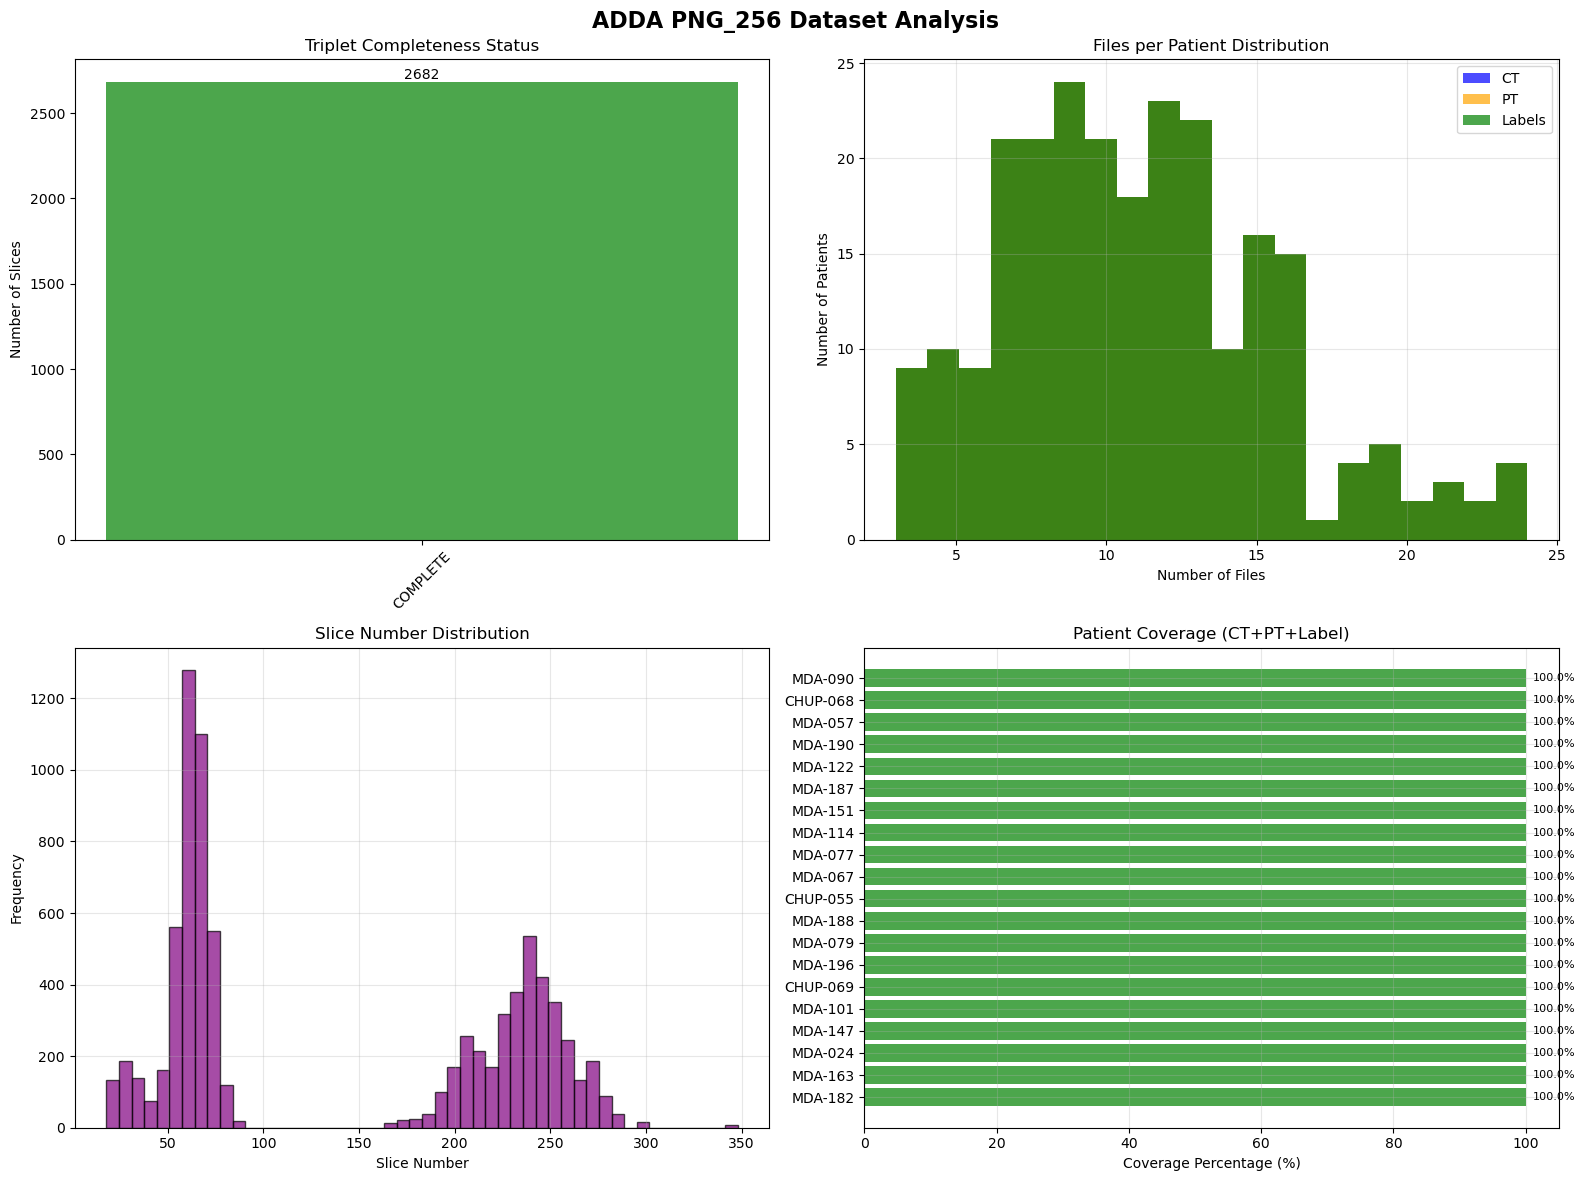


📊 DETAILED STATISTICS:
Average coverage per patient: 100.0%
Patients with 100% coverage: 240
Patients with <50% coverage: 0

💾 Analysis saved to:
  - triplet_analysis.csv
  - patient_coverage.csv


In [13]:
# Create visualizations for the dataset analysis
if 'triplet_df' in locals() and len(triplet_df) > 0:
    # Set up the plotting style
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('ADDA PNG_256 Dataset Analysis', fontsize=16, fontweight='bold')
    
    # 1. Triplet completeness status
    status_counts = triplet_df['status'].value_counts()
    colors = ['green' if status == 'COMPLETE' else 'red' for status in status_counts.index]
    axes[0, 0].bar(status_counts.index, status_counts.values, color=colors, alpha=0.7)
    axes[0, 0].set_title('Triplet Completeness Status')
    axes[0, 0].set_ylabel('Number of Slices')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for i, v in enumerate(status_counts.values):
        axes[0, 0].text(i, v + 0.5, str(v), ha='center', va='bottom')
    
    # 2. Files per patient distribution
    if len(ct_df) > 0:
        ct_per_patient = ct_df.groupby('patient_id').size()
        axes[0, 1].hist(ct_per_patient, bins=min(20, len(ct_per_patient)), alpha=0.7, color='blue', label='CT')
    if len(pt_df) > 0:
        pt_per_patient = pt_df.groupby('patient_id').size()
        axes[0, 1].hist(pt_per_patient, bins=min(20, len(pt_per_patient)), alpha=0.7, color='orange', label='PT')
    if len(label_df) > 0:
        label_per_patient = label_df.groupby('patient_id').size()
        axes[0, 1].hist(label_per_patient, bins=min(20, len(label_per_patient)), alpha=0.7, color='green', label='Labels')
    
    axes[0, 1].set_title('Files per Patient Distribution')
    axes[0, 1].set_xlabel('Number of Files')
    axes[0, 1].set_ylabel('Number of Patients')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Slice number distribution
    all_slices = []
    if len(ct_df) > 0:
        all_slices.extend(ct_df['slice_number'].tolist())
    if len(pt_df) > 0:
        all_slices.extend(pt_df['slice_number'].tolist())
    if len(label_df) > 0:
        all_slices.extend(label_df['slice_number'].tolist())
    
    if all_slices:
        axes[1, 0].hist(all_slices, bins=50, alpha=0.7, color='purple', edgecolor='black')
        axes[1, 0].set_title('Slice Number Distribution')
        axes[1, 0].set_xlabel('Slice Number')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Patient coverage analysis
    patient_coverage = []
    for patient in all_patients:
        patient_ct = len(ct_df[ct_df['patient_id'] == patient]) if len(ct_df) > 0 else 0
        patient_pt = len(pt_df[pt_df['patient_id'] == patient]) if len(pt_df) > 0 else 0
        patient_labels = len(label_df[label_df['patient_id'] == patient]) if len(label_df) > 0 else 0
        
        # Calculate coverage percentage
        max_files = max(patient_ct, patient_pt, patient_labels)
        if max_files > 0:
            coverage = (min(patient_ct, patient_pt, patient_labels) / max_files) * 100
        else:
            coverage = 0
        
        patient_coverage.append({
            'patient_id': patient,
            'ct_files': patient_ct,
            'pt_files': patient_pt,
            'label_files': patient_labels,
            'coverage_pct': coverage
        })
    
    coverage_df = pd.DataFrame(patient_coverage)
    
    # Create a bar chart showing coverage for each patient
    if len(coverage_df) > 0:
        # Sort by coverage percentage
        coverage_df_sorted = coverage_df.sort_values('coverage_pct', ascending=True)
        
        # Show top 20 patients (or all if less than 20)
        display_df = coverage_df_sorted.tail(20) if len(coverage_df_sorted) > 20 else coverage_df_sorted
        
        y_pos = np.arange(len(display_df))
        bars = axes[1, 1].barh(y_pos, display_df['coverage_pct'], alpha=0.7, 
                               color=['green' if x >= 80 else 'orange' if x >= 50 else 'red' for x in display_df['coverage_pct']])
        
        axes[1, 1].set_yticks(y_pos)
        axes[1, 1].set_yticklabels(display_df['patient_id'])
        axes[1, 1].set_xlabel('Coverage Percentage (%)')
        axes[1, 1].set_title('Patient Coverage (CT+PT+Label)')
        axes[1, 1].grid(True, alpha=0.3)
        
        # Add percentage labels on bars
        for i, (bar, pct) in enumerate(zip(bars, display_df['coverage_pct'])):
            axes[1, 1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                           f'{pct:.1f}%', va='center', ha='left', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Additional statistics
    print(f"\n📊 DETAILED STATISTICS:")
    print(f"Average coverage per patient: {coverage_df['coverage_pct'].mean():.1f}%")
    print(f"Patients with 100% coverage: {len(coverage_df[coverage_df['coverage_pct'] == 100])}")
    print(f"Patients with <50% coverage: {len(coverage_df[coverage_df['coverage_pct'] < 50])}")
    
    # Show patients with incomplete coverage
    incomplete_patients = coverage_df[coverage_df['coverage_pct'] < 100].sort_values('coverage_pct')
    if len(incomplete_patients) > 0:
        print(f"\n⚠️  PATIENTS WITH INCOMPLETE COVERAGE:")
        for _, row in incomplete_patients.head(10).iterrows():
            print(f"  {row['patient_id']}: {row['coverage_pct']:.1f}% (CT:{row['ct_files']}, PT:{row['pt_files']}, Label:{row['label_files']})")
    
    # Save detailed analysis
    triplet_df.to_csv('triplet_analysis.csv', index=False)
    coverage_df.to_csv('patient_coverage.csv', index=False)
    print(f"\n💾 Analysis saved to:")
    print(f"  - triplet_analysis.csv")
    print(f"  - patient_coverage.csv")
    
else:
    print("No data available for visualization.")
